#### Setting up the environment
The first step is to set up the conda environment. You should use the `profsea-env.yml` environment file, building it with 

```bash
conda env create -f profsea-env.yml
```

and then activating with `conda activate profsea`.

---

One final step here is to install ProFSea as an editable package, using

```bash 
pip install -e . 
```

while inside the highest level directory.

#### Importing components

The next step is to import all the model components you want to run simulations with - a full list is available in the documention [here](). This can be any combination of available `global` and `spatial` components, how you build your model is up to you!

To generate a comprehensive set of sea-level projections, we'll run with all the components that contribute to sea-level change: 
- thermal expansion
- glaciers
- greenland ice-sheet
- antarctic ice-sheet
- landwater 

In the example below, we'll run with the configuration being used for SLEIP and Munday et al. (2026), *in prep*.

In [1]:
from profsea.components.core.global_model import Global
from profsea.components.global_ import (
    LandwaterAR6,
    GreenlandAR6,
    ThermalExpansion,
    AntarcticaISMIP6,
    Glacier,
)

`ProFSea` can run with a single or an ensemble of temperature and ocean heat content forcing trajectories. The trajectories need to be anomalies, relative to some baseline period - `ProFSea` assumes by default this is `1996-2014`

Here we'll just run with an idealised temperature ramp up and stabilisation, and corresponding ocean heat content change, running from `2006` to `2300`:

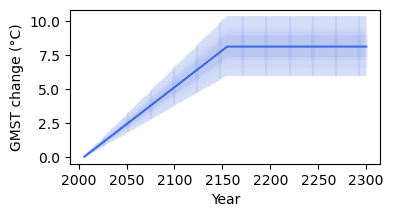

In [2]:
import matplotlib.pyplot as plt
import numpy as np

t_change = np.concatenate(
    [np.linspace(0.01, 8, 150), np.linspace(8, 8, 145)]
)
t_change = t_change[None, :] * np.random.normal(loc=1.0, scale=0.1, size=(100, 1)) # add some variability across members
ohc_change = t_change * 1e24 # in Joules
years = np.arange(2006, 2301)
years = np.broadcast_to(years, t_change.shape)

plt.figure(figsize=(4, 2))
plt.plot(years, t_change, color="royalblue", alpha=0.1)
plt.plot(years.mean(axis=0), t_change.mean(axis=0), color="royalblue", label="GMST change")
plt.xlabel("Year")
plt.ylabel("GMST change (°C)")
plt.show()
plt.close()

#### Building the model

To build your model, simply add your components to a dictionary, with whatever names you like, and pass it to the `Global()` class

In [3]:
global_components = {
    "landwater": LandwaterAR6(),
    "greenland": GreenlandAR6(),
    "expansion": ThermalExpansion(ohc_change), # only the thermal expansion needs OHC change, so we'll pass it in here
    "wais": AntarcticaISMIP6(params_path="../aux_data/wais_params_expanded.nc"),
    "eais": AntarcticaISMIP6(params_path="../aux_data/eais_params_expanded.nc"),
    "peninsula": AntarcticaISMIP6(params_path="../aux_data/pen_params_expanded.nc"),
    "glacier": Glacier(),
}
global_model = Global(components=global_components, end_yr=2301, num_members=1000)

now we're ready to run out simulation!

In [ ]:
projections = global_model.run(
    T_change=t_change,
    scenario="stabilisation",
    member_seed=42
)